# Capstone Project 6: E-commerce Dataset Analysis
## Comprehensive Analysis covering Modules 1-8


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn minisom-1 openpyxl


ERROR: Could not find a version that satisfies the requirement minisom-1 (from versions: none)
ERROR: No matching distribution found for minisom-1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans, DBSCAN, MeanShift
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, silhouette_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')


## Module 1: Data Cleaning
Load data, Clean, Handle Missing Values.


In [3]:
# Load Dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
print('Downloading and loading dataset... this may take a moment.')
df = pd.read_excel(url)
print('Original Data Shape:', df.shape)
df.head()


Original Data Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Initial Cleaning
# Remove records without CustomerID (as we want to analyze customers)
df = df.dropna(subset=['CustomerID'])
# Remove cancelled orders (InvoiceNo starts with C)
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
# Feature Engineering: Total Spend
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']
print('Data Shape after initial cleaning:', df.shape)


Data Shape after initial cleaning: (397924, 9)


In [5]:
# Introduce Artificial Missing Values (5% in Quantity) for Imputation Logic
np.random.seed(42)
df_missing = df.copy()
mask = np.random.rand(len(df_missing)) < 0.05
df_missing.loc[mask, 'Quantity'] = np.nan
print('Missing values in Quantity (Artificially Introduced):', df_missing['Quantity'].isnull().sum())


Missing values in Quantity (Artificially Introduced): 19701


In [6]:
# 1. Simple Imputer (Median)
simple_imputer = SimpleImputer(strategy='median')
qty_simple = simple_imputer.fit_transform(df_missing[['Quantity']])

# 2. KNN Imputer (using small sample for speed as KNN is O(N^2))
knn_imputer = KNNImputer(n_neighbors=5)
# We'll use a subset for KNN demo due to dataset size
subset_size = 5000
df_sample = df_missing[['Quantity', 'UnitPrice']].iloc[:subset_size]
# fit transform on sample
knn_imputed_sample = knn_imputer.fit_transform(df_sample)

# 3. Iterative Imputer
iter_imputer = IterativeImputer(max_iter=10, random_state=0)
iter_imputed_sample = iter_imputer.fit_transform(df_sample)

print('Imputation demonstration complete. Using original cleaned data for further analysis to maintain integrity.')
df_clean = df.copy()


Imputation demonstration complete. Using original cleaned data for further analysis to maintain integrity.


## Module 2: Symmetry Check
Compute Mean, Median, Skewness. Classify Features.


In [7]:
features_to_check = ['Quantity', 'UnitPrice', 'TotalSpend']
stats = pd.DataFrame()
stats['Mean'] = df_clean[features_to_check].mean()
stats['Median'] = df_clean[features_to_check].median()
stats['Skewness'] = df_clean[features_to_check].skew()

def classify_skew(skew):
    if -0.5 <= skew <= 0.5:
        return 'Symmetric'
    elif skew > 0.5:
        return 'Right-Skewed'
    else:
        return 'Left-Skewed'

stats['Skew Analysis'] = stats['Skewness'].apply(classify_skew)
stats


,Mean,Median,Skewness,Skew Analysis
Quantity,13.021823,6.00,403.319431,Right-Skewed
UnitPrice,3.116174,1.95,204.042413,Right-Skewed
TotalSpend,22.394749,11.80,451.465538,Right-Skewed


## Module 3: Data Transformations
Apply Scalers and Transformations (Log/Yeo-Johnson).


In [8]:
# Aggregating data per customer for meaningful analysis
customer_df = df_clean.groupby('CustomerID').agg({
    'TotalSpend': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum'
}).rename(columns={'InvoiceNo': 'Frequency', 'Quantity': 'TotalQuantity'})
# Filter out negative/zero spenders (returns/errors) for transformations
customer_df = customer_df[customer_df['TotalSpend'] > 0]

X_cust = customer_df[['TotalSpend', 'Frequency', 'TotalQuantity']]

# Scalers
scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler(),
    'MaxAbs': MaxAbsScaler()
}
for name, scaler in scalers.items():
    scaler.fit_transform(X_cust)

# Transformations
print('Applying Log Transformation (common for financial data)...')
X_log = np.log1p(X_cust)
print('Skewness after Log Transform:')
print(X_log.skew())

print('\nApplying Yeo-Johnson Transformation...')
pt = PowerTransformer(method='yeo-johnson')
X_transformed = pd.DataFrame(pt.fit_transform(X_cust), columns=X_cust.columns, index=X_cust.index)
print('Skewness after Yeo-Johnson:')
print(X_transformed.skew())


Applying Log Transformation (common for financial data)...
Skewness after Log Transform:
TotalSpend       0.393553
Frequency        1.208700
TotalQuantity    0.040977
dtype: float64

Applying Yeo-Johnson Transformation...
Skewness after Yeo-Johnson:
TotalSpend      -0.014449
Frequency        0.216624
TotalQuantity   -0.002950
dtype: float64


## Module 4: Univariate Data Visualization
Bar plot, Histogram, Box plot.


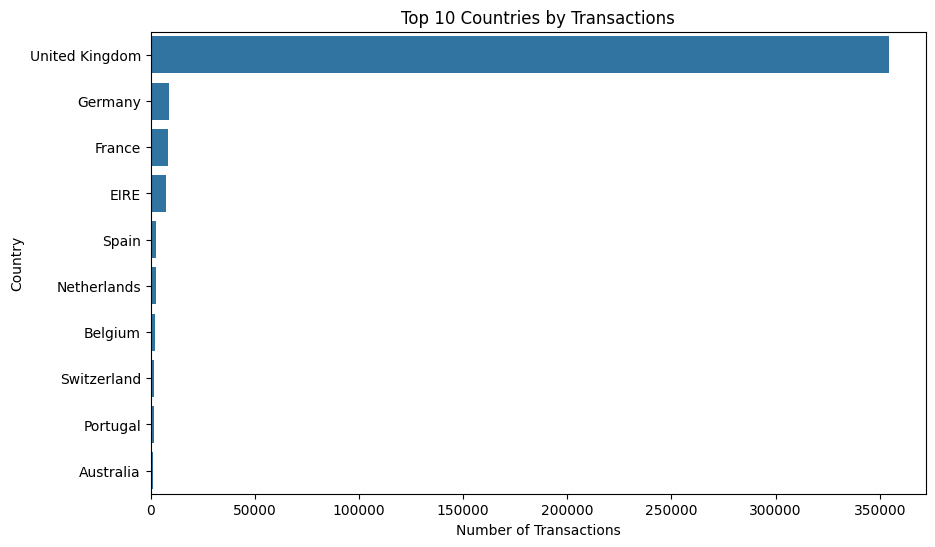

In [9]:
plt.figure(figsize=(10, 6))
top_countries = df_clean['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Transactions')
plt.xlabel('Number of Transactions')
plt.show()


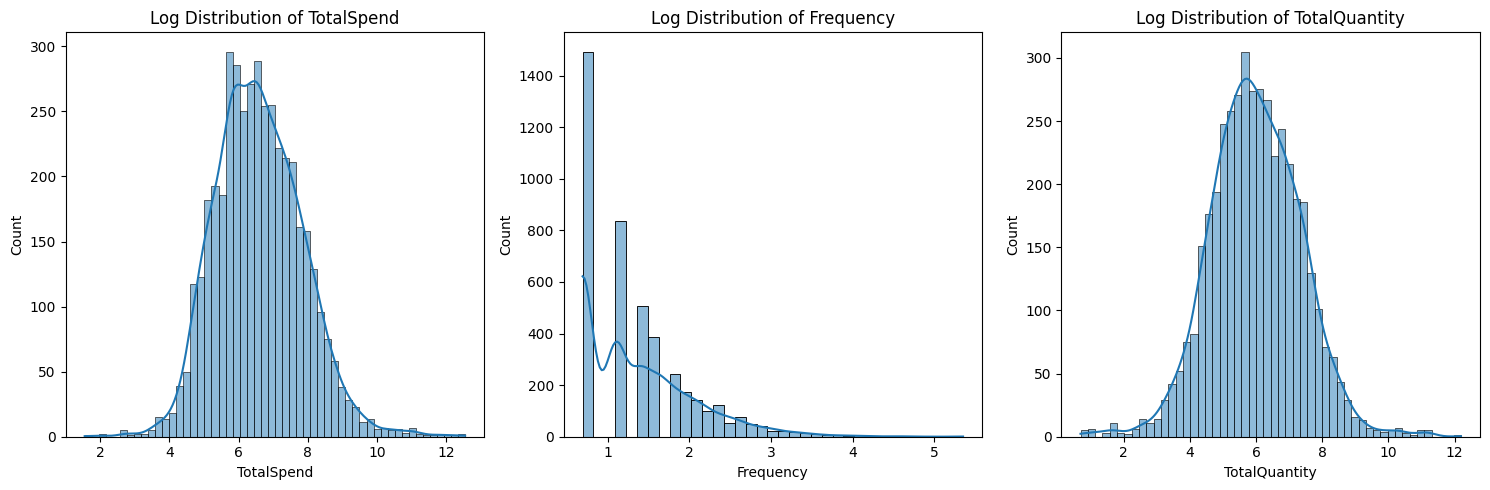

In [10]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['TotalSpend', 'Frequency', 'TotalQuantity']):
    plt.subplot(1, 3, i+1)
    # Using log data for histogram visibility
    sns.histplot(X_log[col], kde=True)
    plt.title(f'Log Distribution of {col}')
plt.tight_layout()
plt.show()


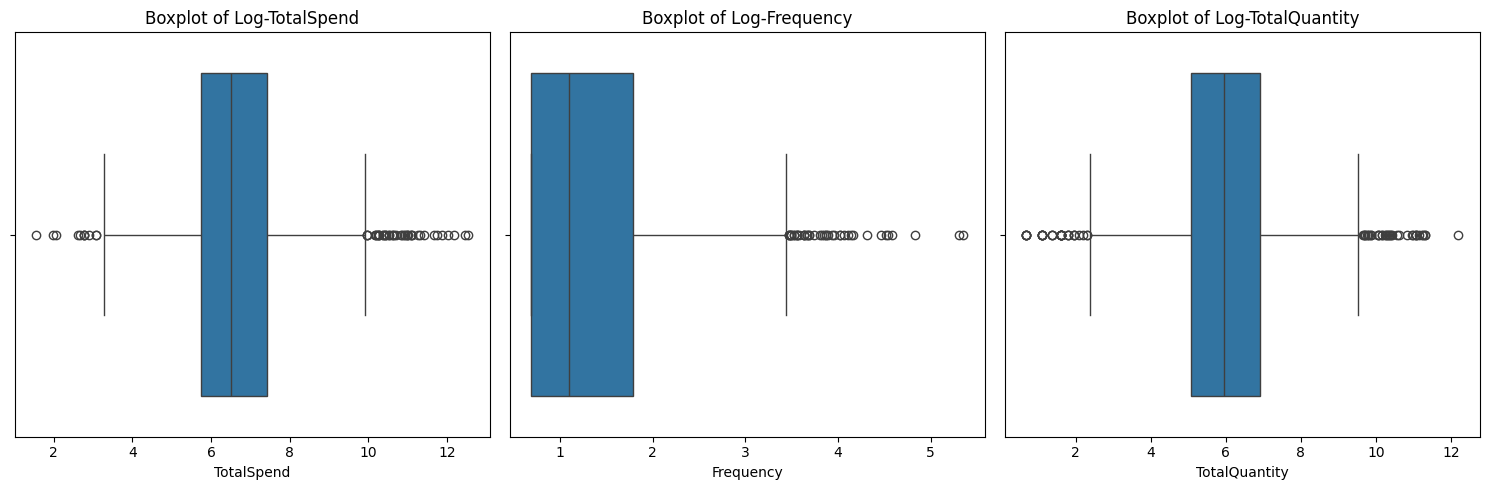

In [11]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['TotalSpend', 'Frequency', 'TotalQuantity']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=X_log[col])
    plt.title(f'Boxplot of Log-{col}')
plt.tight_layout()
plt.show()


## Module 5: Balancing Dataset
Create Classification Target, SMOTE, Undersampling.


In [12]:
# Create Target Class: High Value Customer (Top 30% by Spend)
threshold = customer_df['TotalSpend'].quantile(0.70)
customer_df['IsHighValue'] = (customer_df['TotalSpend'] > threshold).astype(int)
y = customer_df['IsHighValue']
X = X_transformed # Use Yeo-Johnson transformed data

def calculate_entropy(y_target):
    elements, counts = np.unique(y_target, return_counts=True)
    probabilities = counts / len(y_target)
    return -np.sum(probabilities * np.log2(probabilities))

print(f'Entropy Original: {calculate_entropy(y):.4f}')
print('Class Distribution:\n', y.value_counts())

# 1. Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X, y)
print(f'Entropy Undersampled: {calculate_entropy(y_under):.4f}')

# 2. Oversampling (SMOTE)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print(f'Entropy SMOTE: {calculate_entropy(y_smote):.4f}')


Entropy Original: 0.8812
Class Distribution:
 IsHighValue
0    3037
1    1301
Name: count, dtype: int64
Entropy Undersampled: 1.0000
Entropy SMOTE: 1.0000


## Module 6: Supervised Learning
ID3, Bayes, MLP, Linear Regression.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)
models = {}

# a) ID3 Decision Tree
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
models['ID3 Decision Tree'] = dt
print('Decision Tree Rules (First 500 chars):')
print(export_text(dt, feature_names=list(X.columns))[:500])

# b) Bayesian Classifier
nb = GaussianNB()
nb.fit(X_train, y_train)
models['Bayesian Classifier'] = nb

# c) MLP Classifier
mlp = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, activation='relu', random_state=42)
mlp.fit(X_train, y_train)
models['MLP Classifier'] = mlp

# d) Linear Regression (Predicting Exact Spend Amount)
# For regression, we use the continuous target, not the class
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_transformed, np.log1p(customer_df['TotalSpend']), test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_reg_train, y_reg_train)
# Storing separate regression model results
y_reg_pred = lr.predict(X_reg_test)
print('Linear Regression R2 Score (log-spend prediction):', lr.score(X_reg_test, y_reg_test))


Decision Tree Rules (First 500 chars):
|--- TotalSpend <= 0.54
|   |--- class: 0
|--- TotalSpend >  0.54
|   |--- class: 1

Linear Regression R2 Score (log-spend prediction): 0.9924721521208344


## Module 7: Unsupervised Learning
K-Means, SOM, DBSCAN, Mean Shift.


In [14]:
# Using X_transformed (Customer Level Data)
cluster_results = {}

# a) K-Means (Segmentation)
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_transformed)
cluster_results['KMeans'] = labels_kmeans

# b) SOM
som = MiniSom(x=10, y=10, input_len=X_transformed.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_transformed.values)
som.train_random(X_transformed.values, 1000)
labels_som = [str(som.winner(x)) for x in X_transformed.values]
cluster_results['SOM'] = labels_som

# c) DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_transformed)
cluster_results['DBSCAN'] = labels_dbscan

# d) Mean Shift
meanshift = MeanShift()
labels_meanshift = meanshift.fit_predict(X_transformed)
cluster_results['MeanShift'] = labels_meanshift


## Module 8: Performance Metrics
Classification Metrics & Silhouette Score.


In [15]:
for name, model in models.items():
    print(f'--- {name} ---')
    y_pred = model.predict(X_test)
    
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'Recall: {recall_score(y_test, y_pred):.4f}')
    print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f'Specificity: {tn / (tn + fp):.4f}')
    
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test)[:, 1]
        print(f'ROC AUC: {roc_auc_score(y_test, probs):.4f}')
    print('\n')


--- ID3 Decision Tree ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Specificity: 1.0000
ROC AUC: 1.0000


--- Bayesian Classifier ---
Accuracy: 0.9358
Precision: 0.9238
Recall: 0.9558
F1 Score: 0.9395
Specificity: 0.9139
ROC AUC: 0.9866


--- MLP Classifier ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Specificity: 1.0000
ROC AUC: 1.0000




In [16]:
print('--- Clustering Silhouette Scores ---')
for name, labels in cluster_results.items():
    try:
        if name == 'SOM':
            pass
        else:
            unique = len(set(labels))
            if 1 < unique < len(X_transformed):
                sil = silhouette_score(X_transformed, labels, sample_size=5000)
                print(f'{name}: {sil:.4f}')
            else:
                print(f'{name}: Not applicable (1 cluster or noise)')
    except Exception as e:
        print(f'{name}: Error ({e})')


--- Clustering Silhouette Scores ---
KMeans: 0.4124
DBSCAN: 0.2606
MeanShift: 0.4508
